# Codveda Technologies — Level 1, Task 2
## Simple Linear Regression

**Dataset:** Boston Housing (`4) house Prediction Data Set.csv`)

### Objective
Build a **simple linear regression** model that predicts median home value (`MEDV`) from a single predictor.




## 1. Import Required Libraries

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


## 2. Load the Dataset

The supplied Boston Housing file does not contain a header row, so the standard feature names are supplied manually.


In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

DATA_PATH = "datasets/4) house Prediction Data Set.csv"

columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"
]

df = pd.read_csv(
    "/content/4) house Prediction Data Set.csv",
    header=None,
    names=columns,
    sep=r"\s+"
)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Dataset loaded successfully.
Rows: 506
Columns: 14


## 3. Initial Data Inspection

In [3]:
# ============================================================
# 3. INITIAL DATA INSPECTION
# ============================================================

print("First five rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe())


First five rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB

Missing values:


,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0



Duplicate rows:
0

Summary statistics:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## 4. Select the Predictor and Target

We use:

- **`RM`** — average number of rooms per dwelling — as the single predictor
- **`MEDV`** — median home value — as the target

This gives us a genuine simple linear regression problem:

**MEDV = β₀ + β₁(RM)**


In [4]:
# ============================================================
# 4. DEFINE PREDICTOR AND TARGET
# ============================================================

FEATURE = "RM"
TARGET = "MEDV"

X = df[[FEATURE]]
y = df[TARGET]

print(f"Predictor: {FEATURE}")
print(f"Target:    {TARGET}")


Predictor: RM
Target:    MEDV


## 5. Train/Test Split

The model is trained using the training set and evaluated on the unseen test set.


In [5]:
# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training set: {X_train.shape[0]} observations")
print(f"Testing set:  {X_test.shape[0]} observations")


Training set: 404 observations
Testing set:  102 observations


## 6. Train the Simple Linear Regression Model

In [6]:
# ============================================================
# 6. MODEL TRAINING
# ============================================================

model = LinearRegression()

model.fit(X_train, y_train)

print("Simple Linear Regression model trained successfully.")


Simple Linear Regression model trained successfully.


## 7. Interpret the Learned Equation

The regression equation is:

**ŷ = β₀ + β₁x**

where:

- `β₀` is the intercept
- `β₁` is the slope/coefficient
- `x` is the average number of rooms (`RM`)


In [7]:
# ============================================================
# 7. MODEL COEFFICIENTS
# ============================================================

intercept = model.intercept_
coefficient = model.coef_[0]

print(f"Intercept (β₀): {intercept:.4f}")
print(f"Coefficient (β₁): {coefficient:.4f}")

print(
    f"\nRegression equation:"
    f" MEDV = {intercept:.4f} + ({coefficient:.4f} × RM)"
)


Intercept (β₀): -36.2463
Coefficient (β₁): 9.3483

Regression equation: MEDV = -36.2463 + (9.3483 × RM)


## 8. Make Predictions on the Test Set

In [8]:
# ============================================================
# 8. PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

prediction_results = pd.DataFrame({
    "Actual MEDV": y_test.values,
    "Predicted MEDV": y_pred
})

display(prediction_results.head(10))


,Actual MEDV,Predicted MEDV
0,23.6,23.732383
1,32.4,26.929502
2,13.6,19.684568
3,22.8,20.451129
4,16.1,22.619935
5,20.0,22.451666
6,17.8,19.039536
7,14.0,21.470094
8,19.6,21.984251
9,16.8,20.095894


## 9. Evaluate the Model

The task requires:

- **R² (Coefficient of Determination):** measures the proportion of variation in the target explained by the model.
- **MSE (Mean Squared Error):** measures the average squared prediction error.


In [9]:
# ============================================================
# 9. MODEL EVALUATION
# ============================================================

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Score : {r2:.4f}")
print(f"MSE      : {mse:.4f}")


R² Score : 0.3708
MSE      : 46.1448


## 10. Visualize the Regression Line

A scatter plot shows the actual observations, while the regression line shows the model's learned relationship between `RM` and `MEDV`.


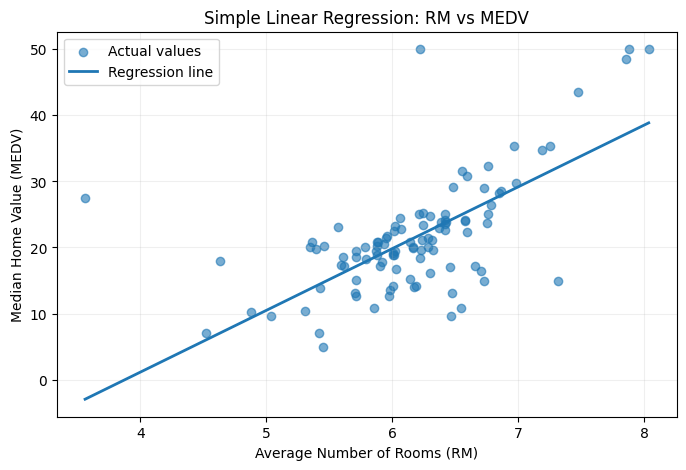

In [10]:
# ============================================================
# 10. REGRESSION LINE VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    X_test[FEATURE],
    y_test,
    alpha=0.6,
    label="Actual values"
)

sorted_indices = np.argsort(X_test[FEATURE].values)

plt.plot(
    X_test[FEATURE].values[sorted_indices],
    y_pred[sorted_indices],
    linewidth=2,
    label="Regression line"
)

plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median Home Value (MEDV)")
plt.title("Simple Linear Regression: RM vs MEDV")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 11. Interpret the Results

The coefficient represents the expected change in `MEDV` for a one-unit increase in `RM`, while holding the simple regression relationship fixed.

A positive coefficient indicates that higher average room counts are associated with higher predicted median home values in this model.

The R² and MSE should be reported using the actual values produced when the notebook is executed.


## 12. Final Summary

In [11]:
# ============================================================
# 12. FINAL SUMMARY
# ============================================================

print("=" * 65)
print("LEVEL 1 - TASK 2: SIMPLE LINEAR REGRESSION SUMMARY")
print("=" * 65)

print(f"Predictor:          {FEATURE}")
print(f"Target:             {TARGET}")
print(f"Intercept:          {intercept:.4f}")
print(f"Coefficient:        {coefficient:.4f}")
print(f"R² Score:           {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

print("\n✓ Dataset loaded and inspected")
print("✓ Predictor and continuous target selected")
print("✓ Train/test split performed")
print("✓ Simple Linear Regression trained")
print("✓ Coefficient and intercept interpreted")
print("✓ R² and MSE calculated")
print("✓ Regression relationship visualized")
print("=" * 65)


LEVEL 1 - TASK 2: SIMPLE LINEAR REGRESSION SUMMARY
Predictor:          RM
Target:             MEDV
Intercept:          -36.2463
Coefficient:        9.3483
R² Score:           0.3708
Mean Squared Error: 46.1448

✓ Dataset loaded and inspected
✓ Predictor and continuous target selected
✓ Train/test split performed
✓ Simple Linear Regression trained
✓ Coefficient and intercept interpreted
✓ R² and MSE calculated
✓ Regression relationship visualized
